In [2]:
%load_ext autoreload
%autoreload 2
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath('..'))

import config
from src.model import train_baseline
from src.evaluation import evaluate_performance, display_mod_performance, get_pr_curve
from src.mrm import score_deciles, get_gains
from src.utils import full_value_counts

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
X_train = pd.read_parquet(config.RESULTS_PATH / 'X_train.parquet')
X_val   = pd.read_parquet(config.RESULTS_PATH / 'X_val.parquet')
y_train = pd.read_parquet(config.RESULTS_PATH / 'y_train.parquet')[config.TARGET]
y_val   = pd.read_parquet(config.RESULTS_PATH / 'y_val.parquet')[config.TARGET]

print(f'X_train: {X_train.shape}')
print(f'X_val:   {X_val.shape}')

X_train: (413378, 431)
X_val:   (88581, 431)


In [4]:
X_train.columns

Index(['TransactionAmt', 'card1', 'card2', 'card3', 'card5', 'addr1', 'addr2',
       'dist1', 'C1', 'C2',
       ...
       'addr1_degree', 'addr1_component_size', 'addr2_pagerank',
       'addr2_pagerank_weighted', 'addr2_degree', 'addr2_component_size',
       'DeviceInfo_pagerank', 'DeviceInfo_pagerank_weighted',
       'DeviceInfo_degree', 'DeviceInfo_component_size'],
      dtype='str', length=431)

## baseline model

In [5]:
model = train_baseline(X_train, y_train)
print(f'trained: {type(model).__name__}  depth={model.get_depth()}  leaves={model.get_n_leaves()}')

trained: DecisionTreeClassifier  depth=10  leaves=431


In [6]:
# check what object columns exist
obj_cols = X_train.select_dtypes(include='object').columns.tolist()
print(f'object columns in X_train: {len(obj_cols)}')
print(obj_cols[:20])

# check if encoded versions exist
encoded_cols = [c for c in X_train.columns if '_encoded' in c]
print(f'\nencoded columns in X_train: {len(encoded_cols)}')
print(encoded_cols[:20])

object columns in X_train: 0
[]

encoded columns in X_train: 26
['ProductCD_encoded', 'card4_encoded', 'card6_encoded', 'P_emaildomain_encoded', 'R_emaildomain_encoded', 'M1_encoded', 'M2_encoded', 'M3_encoded', 'M4_encoded', 'M5_encoded', 'M6_encoded', 'M7_encoded', 'M8_encoded', 'M9_encoded', 'DeviceType_encoded', 'DeviceInfo_encoded', 'id_12_encoded', 'id_15_encoded', 'id_16_encoded', 'id_28_encoded']


## evaluation on validation set

In [7]:
threshold = 0.5
proba = model.predict_proba(X_val)[:, 1]
preds = (proba > threshold).astype(int)

df_scores = pd.DataFrame({'baseline_score': proba})
perf = evaluate_performance(df_scores, 'baseline_score', y_val.values, threshold=threshold)
pd.DataFrame([perf])

,Score,Precision,Recall,F1 Score,Accuracy,PR AUC,AUC,F2 Score,G-Mean,MCC,Gini
0,baseline_score,0.19668,0.62393,0.29909,0.89957,0.35225,0.80576,0.43496,0.35031,0.31171,0.61152


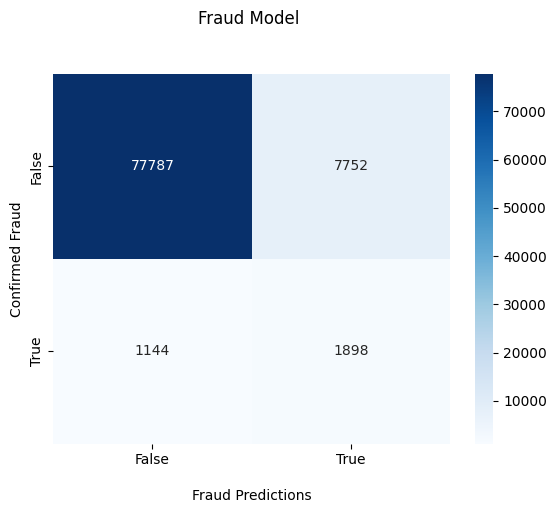

              precision    recall  f1-score   support

           0     0.9855    0.9094    0.9459     85539
           1     0.1967    0.6239    0.2991      3042

    accuracy                         0.8996     88581
   macro avg     0.5911    0.7667    0.6225     88581
weighted avg     0.9584    0.8996    0.9237     88581



In [8]:
display_mod_performance(
    y_val.values, preds,
    save_path=str(config.PLOTS_PATH / 'baseline_confusion_matrix.png'),
)

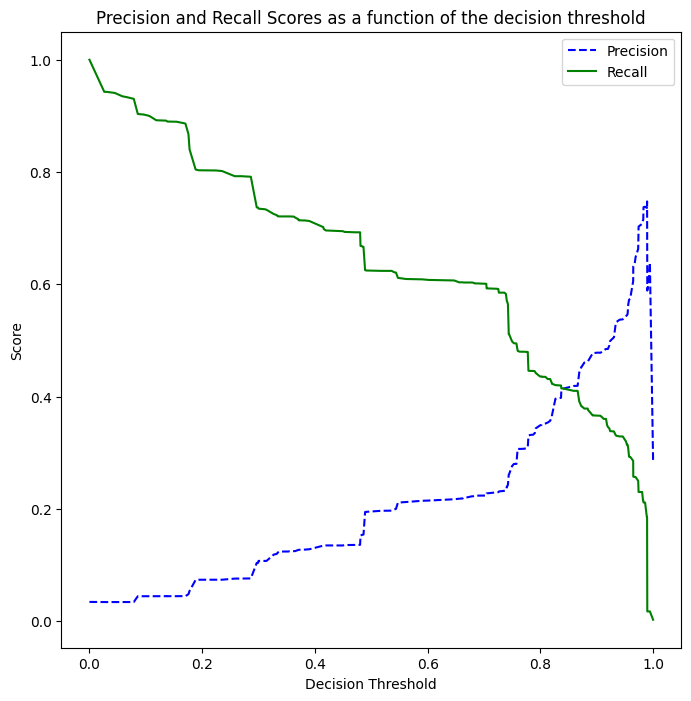

threshold: 0.5


In [9]:
get_pr_curve(y_val.values, proba)
plt.savefig(str(config.PLOTS_PATH / 'baseline_pr_curve.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

print(f'threshold: {threshold}')

## gains and deciles

In [10]:
df_results = pd.DataFrame({
    'TransactionID': range(len(y_val)),
    config.TARGET: y_val.values,
    'baseline_score': proba,
})

decile_table = score_deciles(
    df_results, uid='TransactionID', score='baseline_score', target=config.TARGET
)
display(decile_table)

% frauds captured in top decile: 0.6114


,n_events,baseline_score_thresh,n_frauds,fraud_cm,fraud_pct_cap
decile,,,,,
1,8859,0.543803,1860,1860,0.611440
2,8858,0.333814,333,2193,0.720907
3,8858,0.286302,131,2324,0.763971
4,8858,0.177614,143,2467,0.810980
5,8858,0.177614,60,2527,0.830703
6,8858,0.175626,88,2615,0.859632
7,8858,0.078621,134,2749,0.903682
8,8858,0.078621,34,2783,0.914859
9,8858,0.078621,38,2821,0.927350


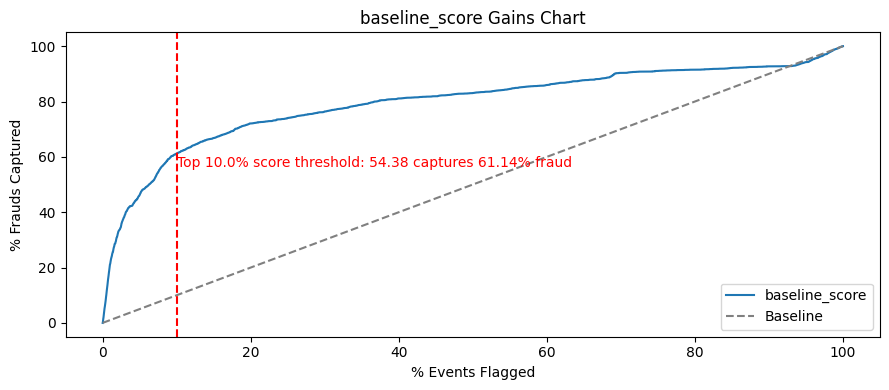

,index,threshold,pct_flagged,n_fraud_cap,fraud_pct_cap
0,baseline_score,0.543803,10.001016,1860.0,61.143984


In [11]:
get_gains(
    df_results, target=config.TARGET, score='baseline_score', top_n=0.1,
    save_path=str(config.PLOTS_PATH / 'baseline_gains.png'),
)

## feature importance

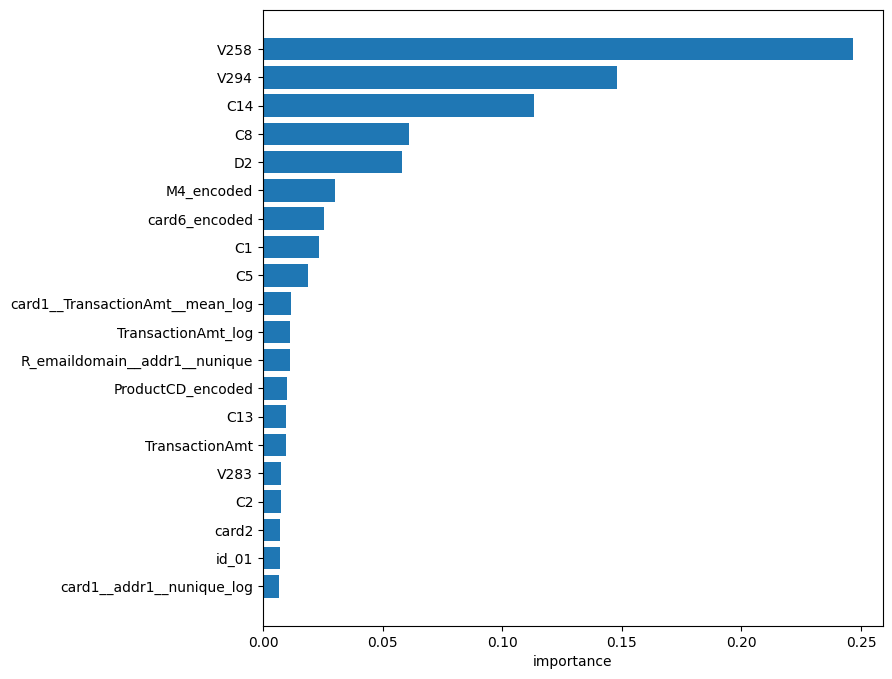

In [12]:
feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
top20 = feat_imp.sort_values(ascending=False).head(20).sort_values()

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(top20.index, top20.values)
ax.set_xlabel('importance')
plt.savefig(str(config.PLOTS_PATH / 'baseline_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

inspect the feature names above to identify which types dominate:
original columns (V*, C*, D*, card*, addr*), aggregation columns (entity__target__agg),
graph columns (*_pagerank, *_pagerank_weighted, *_degree, *_component_size).
graph and aggregation features ranking highly indicates the entity enrichment is adding
signal beyond the raw transaction columns.

## save model

In [13]:
import joblib

models_dir = config.OUTPUT_PATH / 'models'
models_dir.mkdir(exist_ok=True)
joblib.dump(model, str(models_dir / 'baseline.pkl'))
print(f'saved: {models_dir / "baseline.pkl"}')

saved: c:\Users\timot\fraud_model\fraud_model\outputs\models\baseline.pkl
